# Step 2 — Task 3: ML on Pseudobulk PCA (Severity + Variant)

**Two targets, same features:**
1. **Severity (binary)**: WHO ≥ 5 → 1, otherwise 0. Primary headline, consistency with Step 1.
2. **Variant (3-class)**: Ancestral / Delta / Omicron. Secondary — likely a much stronger signal in Secretory expression.

**The biological story we expect:** Variant will be far more predictable than severity from
Secretory pseudobulk expression. This is consistent with the paper's finding that severity-
associated cellular signatures are *variant-conditional* — they exist in Ancestral/Delta but
not in Omicron. The data has stronger variant signal than severity signal in nasal Secretory cells.

**Caveat to flag in slides:** The PCs include information from SARS-CoV-2 viral RNA genes
(top HVGs in Task 2). These directly indicate viral load, which differs strongly between
variants. So part of the variant-prediction AUC is "the model can see viral RNA." This is
real biology but worth being transparent about.

## 3.1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")

CELL_TYPE = "Secretory"  # change to MT-high or Squamous later

## 3.2 — Load PCA features and add the Variant target

In [2]:
# Load the PCA features and severity (saved in Task 2)
pca_df = pd.read_csv(f"step2_{CELL_TYPE}_pca.csv", index_col=0)

# Load patient metadata to get Variant_Group
PT_META_PATH = r"C:\Users\marya\Downloads\Step 1 - Cell Composition\Walsh2025_Supplementary_Table1_Pt_Metadata.csv"
pt = pd.read_csv(PT_META_PATH)
pt.columns = pt.columns.str.strip()

# Merge variant info into our pca_df
variant_map = pt.set_index("Participant")["Variant_Group"]
pca_df["Variant_Group"] = pca_df.index.map(variant_map)

# Build X, and the two targets
pc_cols = [c for c in pca_df.columns if c.startswith("PC")]
X = pca_df[pc_cols].values
y_severity = pca_df["severity"].astype(int).values

# Encode variant as integer for sklearn
variant_codes = {"Ancestral": 0, "Delta": 1, "Omicron": 2}
y_variant = pca_df["Variant_Group"].map(variant_codes).astype(int).values

print(f"X shape: {X.shape}  (patients × PCs)")
print(f"\nSeverity distribution: {dict(zip(*np.unique(y_severity, return_counts=True)))}")
print(f"Variant distribution:")
print(pca_df["Variant_Group"].value_counts())

X shape: (68, 50)  (patients × PCs)

Severity distribution: {np.int64(0): np.int64(25), np.int64(1): np.int64(43)}
Variant distribution:
Variant_Group
Ancestral    29
Delta        23
Omicron      16
Name: count, dtype: int64


## 3.3 — Build the model sets

For binary classification (severity) we use the same models as Step 1.
For multi-class (variant), we adjust XGBoost slightly to handle 3 classes.

In [3]:
def build_models(n_classes, class_balance=None):
    """Return a dict of classifiers configured for binary or multi-class."""
    if n_classes == 2:
        scale_pos_weight = class_balance  # (n_neg / n_pos) for XGBoost binary
        return {
            "Dummy (majority)": DummyClassifier(strategy="most_frequent"),
            "Random Forest": RandomForestClassifier(
                n_estimators=500, max_depth=5, class_weight="balanced",
                random_state=42, n_jobs=-1),
            "LightGBM": LGBMClassifier(
                n_estimators=300, max_depth=3, learning_rate=0.05,
                class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1),
            "XGBoost": XGBClassifier(
                n_estimators=300, max_depth=3, learning_rate=0.05,
                scale_pos_weight=scale_pos_weight,
                random_state=42, n_jobs=-1, eval_metric="logloss"),
        }
    else:
        return {
            "Dummy (majority)": DummyClassifier(strategy="most_frequent"),
            "Random Forest": RandomForestClassifier(
                n_estimators=500, max_depth=5, class_weight="balanced",
                random_state=42, n_jobs=-1),
            "LightGBM": LGBMClassifier(
                n_estimators=300, max_depth=3, learning_rate=0.05,
                class_weight="balanced", objective="multiclass",
                num_class=n_classes, random_state=42, n_jobs=-1, verbose=-1),
            "XGBoost": XGBClassifier(
                n_estimators=300, max_depth=3, learning_rate=0.05,
                objective="multi:softprob", num_class=n_classes,
                random_state=42, n_jobs=-1, eval_metric="mlogloss"),
        }

## 3.4 — One pipeline function for both targets

This runs 5-fold CV across all models for any target. Returns a results DataFrame and
the cross-validated probabilities for the winning model.

In [4]:
def run_pipeline(X, y, target_name, n_classes):
    """Run model comparison + 20-seed CV + bootstrap CI for one target."""
    print(f"\n{'='*60}\n  Target: {target_name} ({n_classes} classes)\n{'='*60}")

    # Choose scoring based on number of classes
    if n_classes == 2:
        scoring = "roc_auc"
        scale = (y == 0).sum() / (y == 1).sum()
        models = build_models(n_classes, class_balance=scale)
    else:
        scoring = "roc_auc_ovr_weighted"  # one-vs-rest AUC, weighted by class size
        models = build_models(n_classes)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = []
    all_proba = {}

    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
        if name != "Dummy (majority)":
            try:
                proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba")
                all_proba[name] = proba
            except Exception:
                pass
        results.append({
            "Model": name,
            "Mean AUC": scores.mean(),
            "Std": scores.std(),
            "Min fold": scores.min(),
            "Max fold": scores.max(),
        })

    results_df = pd.DataFrame(results).sort_values("Mean AUC", ascending=False)
    print(f"\n[5-fold CV, scoring={scoring}]")
    print(results_df.to_string(index=False))

    # 20-seed sanity check on the top non-dummy model
    top = results_df[results_df["Model"] != "Dummy (majority)"].iloc[0]["Model"]
    seed_aucs = []
    for seed in range(20):
        cv_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        seed_aucs.append(cross_val_score(models[top], X, y, cv=cv_s, scoring=scoring).mean())
    print(f"\n[20-seed CV] {top}: {np.mean(seed_aucs):.3f} ± {np.std(seed_aucs):.3f}")

    return results_df, all_proba, top, np.mean(seed_aucs), np.std(seed_aucs)

## 3.5 — Run for SEVERITY (primary target)

In [5]:
sev_results, sev_proba, sev_top, sev_mean, sev_std = run_pipeline(
    X, y_severity, "Severity (WHO ≥ 5)", n_classes=2,
)


  Target: Severity (WHO ≥ 5) (2 classes)


c:\Users\marya\Downloads\Step 2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\marya\Downloads\Step 2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\marya\Downloads\Step 2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\marya\Downloads\Step 2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\marya\Downloads\Step 2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with f


[5-fold CV, scoring=roc_auc]
           Model  Mean AUC      Std  Min fold  Max fold
   Random Forest  0.768333 0.067942     0.675  0.844444
         XGBoost  0.658333 0.124994     0.500  0.822222
        LightGBM  0.657778 0.087390     0.550  0.777778
Dummy (majority)  0.500000 0.000000     0.500  0.500000

[20-seed CV] Random Forest: 0.734 ± 0.038


## 3.6 — Run for VARIANT (secondary target)

In [6]:
var_results, var_proba, var_top, var_mean, var_std = run_pipeline(
    X, y_variant, "Variant (Ancestral / Delta / Omicron)", n_classes=3,
)


  Target: Variant (Ancestral / Delta / Omicron) (3 classes)


c:\Users\marya\Downloads\Step 2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\marya\Downloads\Step 2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\marya\Downloads\Step 2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\marya\Downloads\Step 2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\marya\Downloads\Step 2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with f


[5-fold CV, scoring=roc_auc_ovr_weighted]
           Model  Mean AUC      Std  Min fold  Max fold
         XGBoost  0.847640 0.117449  0.638462  0.985714
   Random Forest  0.823798 0.076423  0.729076  0.921429
        LightGBM  0.768304 0.106142  0.592308  0.919643
Dummy (majority)  0.500000 0.000000  0.500000  0.500000

[20-seed CV] XGBoost: 0.823 ± 0.027


All real models use shallow trees (max_depth=3 or 5). This is intentional — with only ~68 patients, deep trees would memorise the training data (overfit) and give falsely high scores.

## 3.7 — Side-by-side comparison

           Target     Top model  20-seed mean AUC  20-seed std
Severity (binary) Random Forest          0.734389     0.037774
Variant (3-class)       XGBoost          0.823030     0.026979


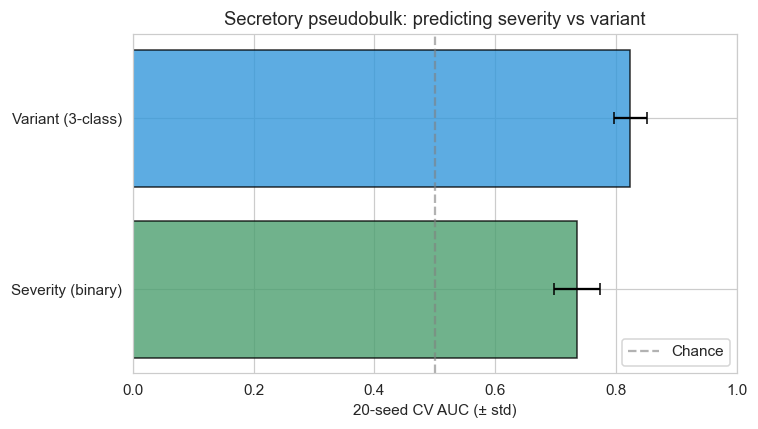

In [7]:
comparison = pd.DataFrame({
    "Target": ["Severity (binary)", "Variant (3-class)"],
    "Top model": [sev_top, var_top],
    "20-seed mean AUC": [sev_mean, var_mean],
    "20-seed std": [sev_std, var_std],
})
print(comparison.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(comparison["Target"], comparison["20-seed mean AUC"],
        xerr=comparison["20-seed std"],
        color=["#4C9F70", "#3498DB"], alpha=0.8, capsize=4, edgecolor="black")
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.6, label="Chance")
ax.set_xlim(0, 1)
ax.set_xlabel("20-seed CV AUC (± std)")
ax.set_title(f"{CELL_TYPE} pseudobulk: predicting severity vs variant")
ax.legend()
plt.tight_layout()
plt.show()

 secretory cell gene expression is more tightly linked to which virus strain a patient had than to how sick they got.

## 3.8 — Comparison to Step 1 composition baseline (severity only)

In [8]:
COMP_PATH = r"C:\Users\marya\Downloads\Step 1 - Cell Composition\cell_type_fractions.csv"
composition = pd.read_csv(COMP_PATH, index_col=0)

shared_patients = composition.index.intersection(pca_df.index)
X_comp = composition.loc[shared_patients].values
y_comp = pca_df.loc[shared_patients, "severity"].astype(int).values

rf_baseline = RandomForestClassifier(
    n_estimators=500, max_depth=5, class_weight="balanced",
    random_state=42, n_jobs=-1,
)
baseline_seeds = []
for seed in range(20):
    cv_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    baseline_seeds.append(
        cross_val_score(rf_baseline, X_comp, y_comp, cv=cv_s, scoring="roc_auc").mean()
    )

# Combined: composition + PCs
X_combined = np.hstack([composition.loc[shared_patients].values,
                       pca_df.loc[shared_patients, pc_cols].values])
combined_seeds = []
for seed in range(20):
    cv_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    combined_seeds.append(
        cross_val_score(rf_baseline, X_combined, y_comp, cv=cv_s, scoring="roc_auc").mean()
    )

# Full comparison
print("\n=== Severity prediction: feature set comparison ===")
full_comp = pd.DataFrame([
    {"Feature set": "Composition only (matched n)",        "AUC": np.mean(baseline_seeds),
     "Std": np.std(baseline_seeds)},
    {"Feature set": f"{CELL_TYPE} PCs only",               "AUC": sev_mean, "Std": sev_std},
    {"Feature set": f"Composition + {CELL_TYPE} PCs",      "AUC": np.mean(combined_seeds),
     "Std": np.std(combined_seeds)},
])
print(full_comp.to_string(index=False))


=== Severity prediction: feature set comparison ===
                 Feature set      AUC      Std
Composition only (matched n) 0.704306 0.032535
          Secretory PCs only 0.734389 0.037774
 Composition + Secretory PCs 0.752722 0.031152


## 3.9 — ROC curves (severity only)

note:: multi-class ROC is harder to visualise (you'd need one curve per variant)

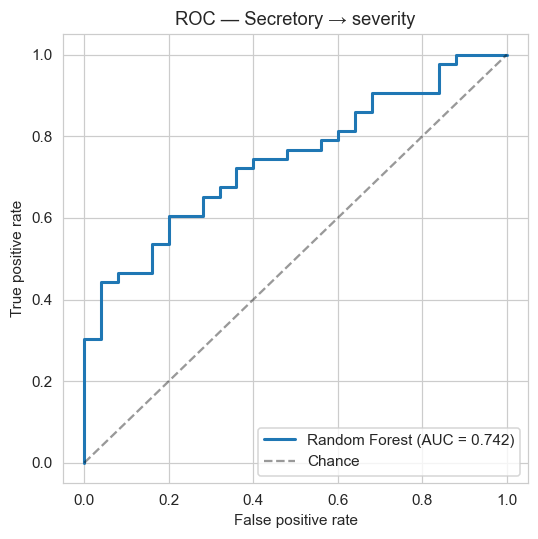

In [11]:
if sev_top in sev_proba:
    proba_pos = sev_proba[sev_top][:, 1]
    fpr, tpr, _ = roc_curve(y_severity, proba_pos)
    auc_value = roc_auc_score(y_severity, proba_pos)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(fpr, tpr, lw=2, label=f"{sev_top} (AUC = {auc_value:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"ROC — {CELL_TYPE} → severity")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

This AUC is from a single seed (not the 20-seed average), so it may differ slightly from 3.5.

## 3.10 — Feature importance for both targets

Which PCs matter for each? They might be different — severity-relevant PCs vs
variant-relevant PCs are not necessarily the same dimensions of variation.

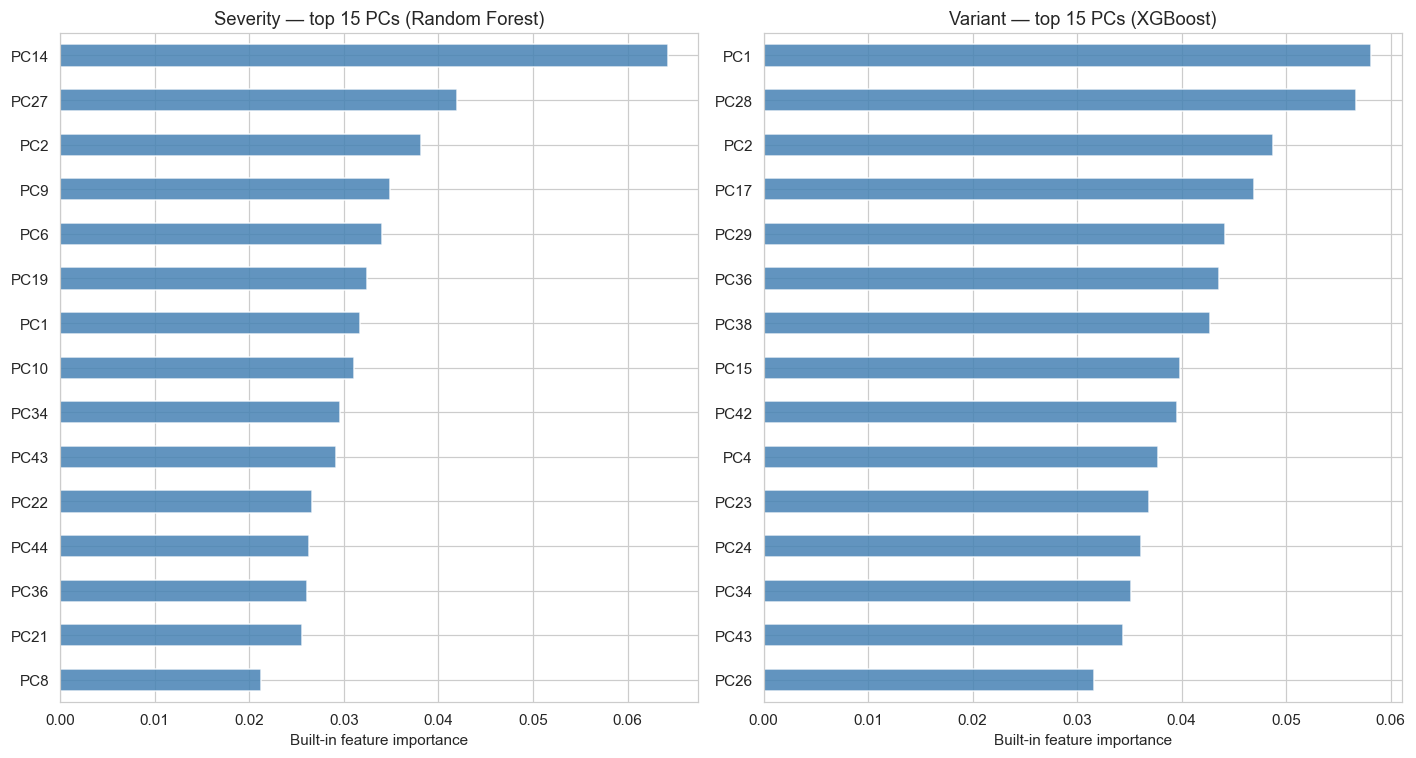

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7))

for ax, (target_name, y_target, top_model_name) in zip(
    axes,
    [("Severity", y_severity, sev_top),
     ("Variant", y_variant, var_top)],
):
    n_classes = len(np.unique(y_target))
    if n_classes == 2:
        scale = (y_target == 0).sum() / (y_target == 1).sum()
        model = build_models(n_classes, class_balance=scale)[top_model_name]
    else:
        model = build_models(n_classes)[top_model_name]

    model.fit(X, y_target)
    
    # Use model's built-in feature_importances_ instead of permutation
    feat_imp = pd.Series(model.feature_importances_, index=pc_cols).sort_values()
    feat_imp.tail(15).plot(kind="barh", ax=ax, color="steelblue", alpha=0.85)
    ax.set_title(f"{target_name} — top 15 PCs ({top_model_name})")
    ax.set_xlabel("Built-in feature importance")

plt.tight_layout()
plt.show()

## 3.11 — Genes driving the top severity-predictive PCs

Bridge back to biology: which genes are loaded on the PCs that matter for severity?

In [17]:
# Use built-in importance for severity
sev_scale = (y_severity == 0).sum() / (y_severity == 1).sum()
sev_model = build_models(2, class_balance=sev_scale)[sev_top]
sev_model.fit(X, y_severity)

sev_imp = pd.Series(sev_model.feature_importances_, index=pc_cols).sort_values(ascending=False)
top_3_pcs_sev = sev_imp.head(3).index.tolist()

print(f"\nTop 3 severity-predictive PCs: {top_3_pcs_sev}\n")
for pc in top_3_pcs_sev:
    pc_loadings = loadings.loc[pc].sort_values()
    print(f"=== {pc} (importance = {sev_imp[pc]:.4f}) ===")
    print(f"  Top + genes: {pc_loadings.tail(8).index.tolist()[::-1]}")
    print(f"  Top - genes: {pc_loadings.head(8).index.tolist()}")
    print()


Top 3 severity-predictive PCs: ['PC14', 'PC27', 'PC2']

=== PC14 (importance = 0.0642) ===
  Top + genes: ['IL2RA', 'AL591543.1', 'AC079612.1', 'AL137067.1', 'C17orf50', 'AC007159.1', 'AL031705.1', 'AL121956.4']
  Top - genes: ['NABP1', 'ZNF117', 'CCNE2', 'KATNBL1', 'INTS6', 'CCDC93', 'QKI', 'CPA4']

=== PC27 (importance = 0.0420) ===
  Top + genes: ['RFPL3', 'TOX2', 'VASH1', 'RADIL', 'LINC02334', 'KIF9', 'MAP3K19', 'CCDC141']
  Top - genes: ['AL645634.2', 'LINC01871', 'ZSCAN1', 'ZNF334', 'SLC5A3', 'CENPJ', 'AL139020.1', 'SYNPO2L']

=== PC2 (importance = 0.0381) ===
  Top + genes: ['GSTM5', 'AC008543.5', 'MNX1-AS1', 'HSD3B2', 'LINC01164', 'LAMC3', 'KIAA0087', 'FSHR']
  Top - genes: ['AC106738.2', 'TNFRSF8', 'AL035250.1', 'CRTAC1', 'LINC00114', 'KLK2', 'AL356259.1', 'TLR8']

